# 03 · Ciclo de vida

Ciclo de vida de una canción en el chart (forma de onda: subida, pico, caída).

In [8]:
import sys
sys.path.append("..")

from src import utils

En este notebook se analiza el ciclo de vida de una canción dentro del chart argentino de Spotify. A partir de lo explorado en el notebook `02_resumen_general`, se seleccionó **“Tusa” — KAROL G, Nicki Minaj** por su permanencia prolongada en el Top 50 argentino y por haber alcanzado el puesto 1.

La canción será tratada como una señal temporal discreta: cada muestra corresponde a un día y el valor de la señal representa la cantidad de streams registrados en Argentina.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RUTA = "../data/charts_argentina.csv"

df_ar = pd.read_csv(RUTA, parse_dates=["date"])
df_ar.head()

,title,rank,date,artist,url,region,chart,trend,streams
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0
1,24K Magic,34,2017-01-01,Bruno Mars,https://open.spotify.com/track/6b8Be6ljOzmkOmF...,Argentina,top200,MOVE_DOWN,58801.0
2,CAN'T STOP THE FEELING! (Original Song from Dr...,35,2017-01-01,Justin Timberlake,https://open.spotify.com/track/6JV2JOEocMgcZxY...,Argentina,top200,MOVE_UP,56170.0
3,Fuego,36,2017-01-01,Juanes,https://open.spotify.com/track/0mwPE0lPOgnWf2b...,Argentina,top200,MOVE_UP,55902.0
4,Bobo,37,2017-01-01,J Balvin,https://open.spotify.com/track/7AtlMCIauSQZqiX...,Argentina,top200,MOVE_UP,55360.0


In [10]:
CANCION = "Tusa"
ARTISTA = "KAROL G, Nicki Minaj"

df_tusa = df_ar[
    (df_ar["title"] == CANCION) &
    (df_ar["artist"] == ARTISTA) &
    (df_ar["chart"] == "top200") &
    (df_ar["rank"] <= 50)
].sort_values("date").copy()

df_tusa[["date", "title", "artist", "rank", "streams"]].head()

,date,title,artist,rank,streams
262142,2019-11-19,Tusa,"KAROL G, Nicki Minaj",43,73707.0
262309,2019-11-20,Tusa,"KAROL G, Nicki Minaj",32,86089.0
262667,2019-11-21,Tusa,"KAROL G, Nicki Minaj",24,101383.0
262937,2019-11-22,Tusa,"KAROL G, Nicki Minaj",23,123424.0
263186,2019-11-23,Tusa,"KAROL G, Nicki Minaj",22,128233.0


In [11]:
df_tusa[["date", "title", "artist", "rank", "streams"]].tail()

,date,title,artist,rank,streams
365533,2021-01-06,Tusa,"KAROL G, Nicki Minaj",48,72504.0
365909,2021-01-07,Tusa,"KAROL G, Nicki Minaj",47,81250.0
366267,2021-01-08,Tusa,"KAROL G, Nicki Minaj",49,86065.0
366437,2021-01-09,Tusa,"KAROL G, Nicki Minaj",49,93155.0
366530,2021-01-10,Tusa,"KAROL G, Nicki Minaj",48,89769.0


Definimos la serie temporal de la canción seleccionada tomando como eje temporal la fecha y como valor la cantidad diaria de streams. En este caso, cada muestra representa un día, por lo que la frecuencia de muestreo es de 1 muestra por día.

In [12]:
serie_tusa = utils.construir_serie(
    df_ar,
    {
        "title": CANCION,
        "artist": ARTISTA,
        "region": "Argentina",
        "chart": "top200",
        "valor": "streams",
        "agregado": "sum"
    }
)

serie_tusa = serie_tusa[serie_tusa.index.isin(df_tusa["date"])]

serie_tusa.head()

date
2019-11-19     73707.0
2019-11-20     86089.0
2019-11-21    101383.0
2019-11-22    123424.0
2019-11-23    128233.0
Name: streams, dtype: float64

In [13]:
serie_tusa.tail()

date
2021-01-06    72504.0
2021-01-07    81250.0
2021-01-08    86065.0
2021-01-09    93155.0
2021-01-10    89769.0
Name: streams, dtype: float64

In [14]:
print(f"Cantidad de muestras: {len(serie_tusa)}")
print(f"Fecha inicial: {serie_tusa.index.min().date()}")
print(f"Fecha final: {serie_tusa.index.max().date()}")
print(f"Frecuencia de muestreo: 1 muestra por día")

Cantidad de muestras: 363
Fecha inicial: 2019-11-19
Fecha final: 2021-01-10
Frecuencia de muestreo: 1 muestra por día


La serie construida para **“Tusa”** tiene 363 muestras diarias, desde el 19 de noviembre de 2019 hasta el 10 de enero de 2021. Como cada observación corresponde a un día, la frecuencia de muestreo es de 1 muestra por día. Esta longitud permite aplicar herramientas de análisis temporal y frecuencial, como visualización de la forma de onda, filtrado, energía y autocorrelación.

Primero observamos la serie en el dominio del tiempo. En este gráfico, el eje horizontal representa la fecha y el eje vertical representa la cantidad diaria de streams. Esta visualización permite identificar visualmente las etapas del ciclo de vida de la canción: crecimiento, pico y caída.

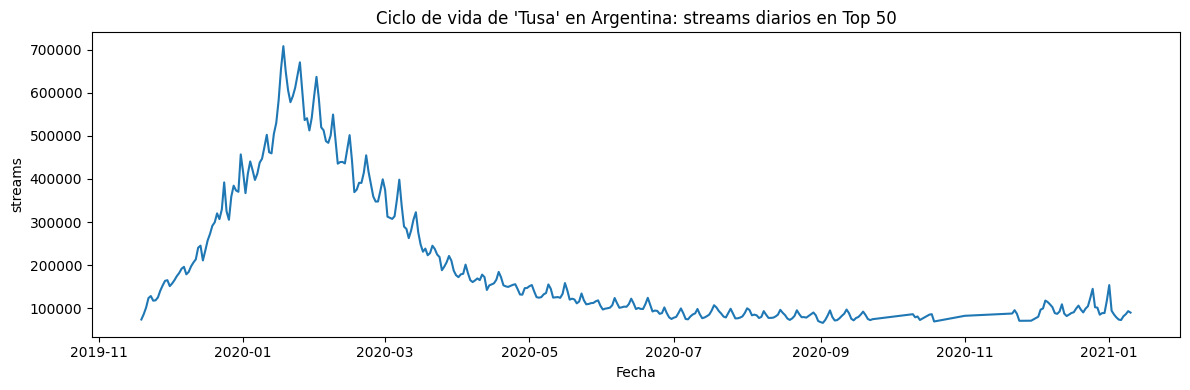

In [15]:
utils.graficar_serie(
    serie_tusa,
    "Ciclo de vida de 'Tusa' en Argentina: streams diarios en Top 50"
)

plt.show()

Luego de observar la forma general de la serie, calculamos algunas medidas descriptivas básicas: media, desvío estándar y rango. Estas medidas permiten resumir el nivel promedio de streams, la variabilidad de la señal y la diferencia entre sus valores máximo y mínimo.

In [16]:
resumen_tusa = utils.resumen_estadistico(serie_tusa)

resumen_tusa

{'media': 195504.31955922864, 'desvio': 152409.03005300803, 'rango': 642544.0}

El promedio diario de streams de **“Tusa”** durante su permanencia en el Top 50 argentino fue de aproximadamente **195.504 reproducciones**. El desvío estándar, de aproximadamente **152.409**, muestra una variabilidad alta, coherente con el ciclo de vida de una canción popular: crecimiento inicial, pico de popularidad y posterior caída. El rango de **642.544 streams** indica una diferencia marcada entre los días de menor y mayor reproducción.

In [17]:
fecha_max = serie_tusa.idxmax()
valor_max = serie_tusa.max()

fecha_min = serie_tusa.idxmin()
valor_min = serie_tusa.min()

print(f"Máximo: {valor_max:,.0f} streams el {fecha_max.date()}")
print(f"Mínimo: {valor_min:,.0f} streams el {fecha_min.date()}")

Máximo: 708,411 streams el 2020-01-18
Mínimo: 65,867 streams el 2020-09-02


El valor máximo de la serie se alcanza el **18 de enero de 2020**, con **708.411 streams**, lo que puede interpretarse como el pico de popularidad de la canción dentro del Top 50 argentino. El mínimo dentro del período analizado aparece el **2 de septiembre de 2020**, con **65.867 streams**. La diferencia entre estos valores refuerza la idea de un ciclo de vida marcado: la canción crece hasta un pico y luego pierde intensidad dentro del chart.

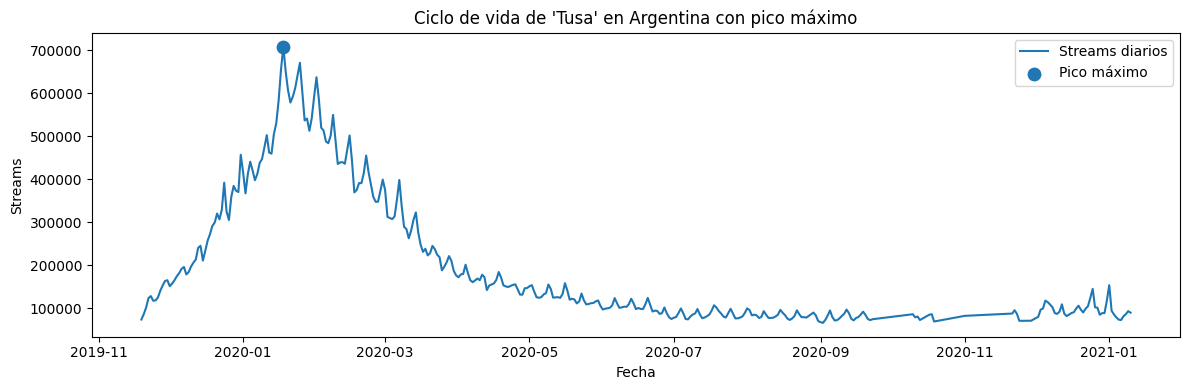

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(serie_tusa.index, serie_tusa.values, label="Streams diarios")
plt.scatter(fecha_max, valor_max, s=80, label="Pico máximo")
plt.title("Ciclo de vida de 'Tusa' en Argentina con pico máximo")
plt.xlabel("Fecha")
plt.ylabel("Streams")
plt.legend()
plt.tight_layout()
plt.show()

Para separar la forma general de la serie de las variaciones diarias, aplicamos filtros de media móvil. La media móvil de 7 días permite suavizar fluctuaciones de corto plazo asociadas a variaciones diarias o semanales, mientras que la media móvil de 21 días permite observar una tendencia más general del ciclo de vida de la canción.

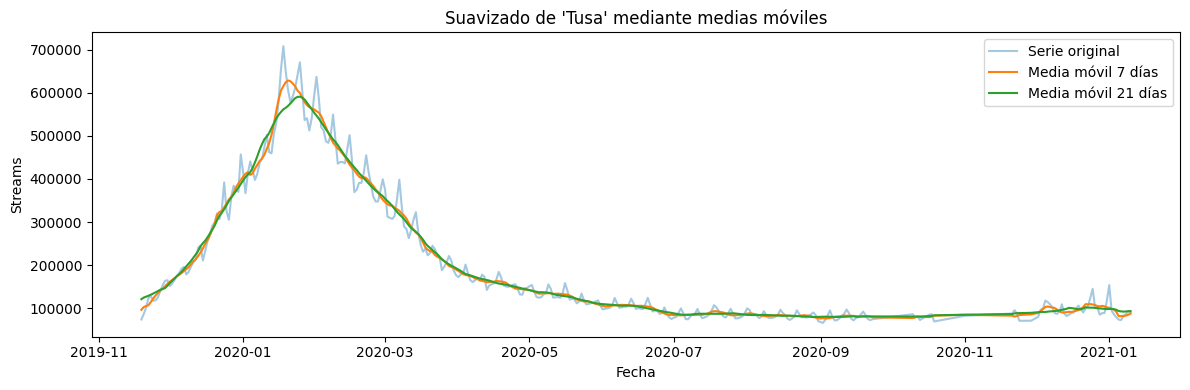

In [19]:
ma7_tusa = utils.filtro_media_movil(serie_tusa, 7)
ma21_tusa = utils.filtro_media_movil(serie_tusa, 21)

plt.figure(figsize=(12, 4))
plt.plot(serie_tusa.index, serie_tusa.values, alpha=0.4, label="Serie original")
plt.plot(ma7_tusa.index, ma7_tusa.values, label="Media móvil 7 días")
plt.plot(ma21_tusa.index, ma21_tusa.values, label="Media móvil 21 días")
plt.title("Suavizado de 'Tusa' mediante medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Streams")
plt.legend()
plt.tight_layout()
plt.show()

El suavizado permite observar con mayor claridad el ciclo de vida de la canción. La serie original presenta variaciones diarias fuertes, mientras que la media móvil de 7 días reduce parte de ese ruido de corto plazo. La media móvil de 21 días muestra una tendencia más general: un crecimiento inicial hasta el pico de popularidad y luego una caída progresiva de los streams.

Aplicamos la descomposición basada en medias móviles definida en `utils.py`. Esta separación permite aproximar tres componentes de la señal: una tendencia de baja frecuencia, una componente estacional o intermedia y un residuo asociado a variaciones de alta frecuencia.

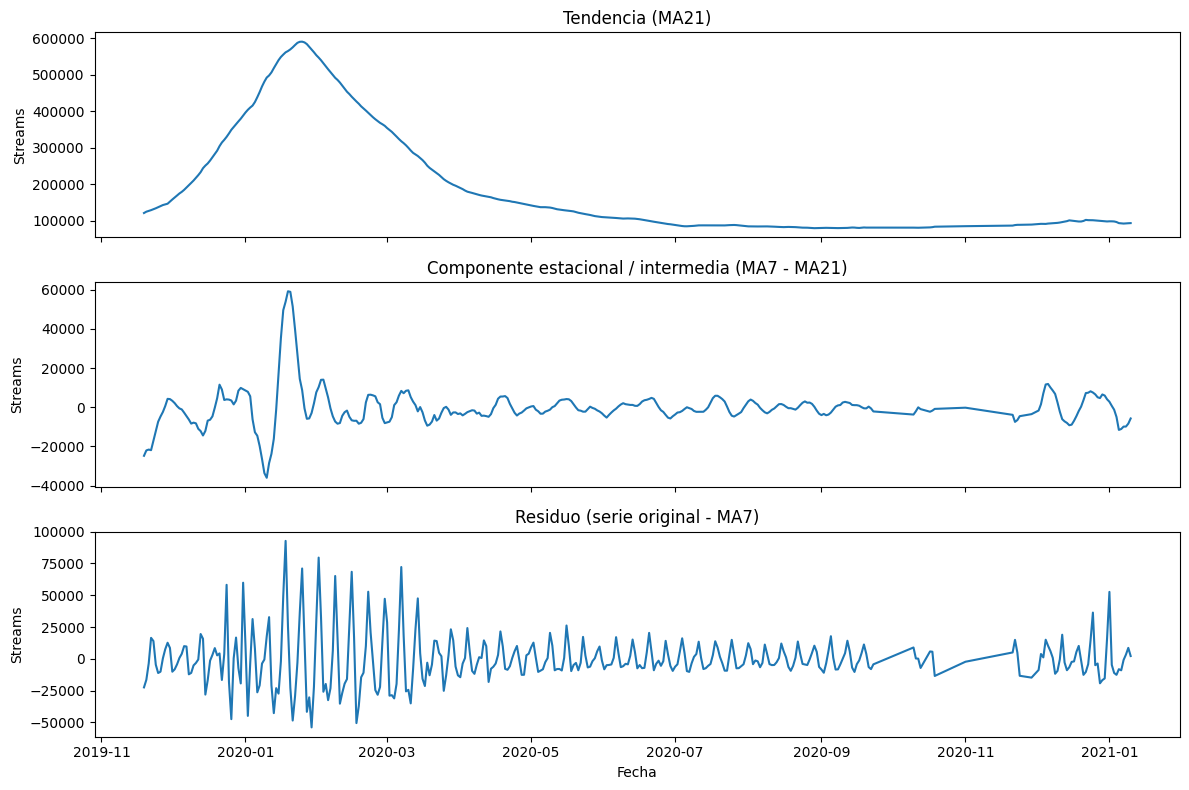

In [20]:
desc_tusa = utils.descomponer_MA7_MA21(serie_tusa)

fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

ax[0].plot(desc_tusa["tendencia"])
ax[0].set_title("Tendencia (MA21)")
ax[0].set_ylabel("Streams")

ax[1].plot(desc_tusa["estacional"])
ax[1].set_title("Componente estacional / intermedia (MA7 - MA21)")
ax[1].set_ylabel("Streams")

ax[2].plot(desc_tusa["residuo"])
ax[2].set_title("Residuo (serie original - MA7)")
ax[2].set_ylabel("Streams")
ax[2].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

La descomposición muestra tres niveles de análisis. La tendencia, aproximada mediante MA21, resume el movimiento general de largo plazo de la canción en el chart. La componente intermedia, calculada como MA7 - MA21, captura oscilaciones más cortas alrededor de esa tendencia. Finalmente, el residuo representa las variaciones diarias que no quedan explicadas por el suavizado de 7 días, es decir, cambios más abruptos o ruido de alta frecuencia.

Luego de analizar la serie en el dominio del tiempo, aplicamos la Transformada de Fourier para observar su representación en el dominio de la frecuencia. Como el muestreo es diario, las frecuencias se interpretan en ciclos por día. Este análisis permite identificar si existen periodicidades dominantes, por ejemplo ciclos semanales.

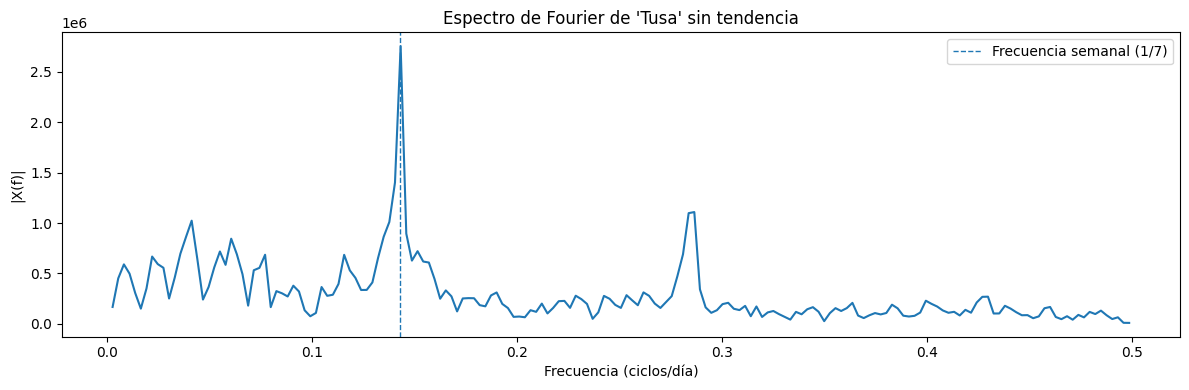

In [21]:
# Para que la tendencia no domine todo el espectro, analizamos la serie sin su tendencia MA21.
serie_sin_tendencia = serie_tusa - desc_tusa["tendencia"]

frecs_tusa, mags_tusa = utils.calcular_fft(serie_sin_tendencia.dropna())

utils.graficar_espectro(
    frecs_tusa,
    mags_tusa,
    "Espectro de Fourier de 'Tusa' sin tendencia"
)

plt.axvline(1/7, linestyle="--", linewidth=1, label="Frecuencia semanal (1/7)")
plt.legend()
plt.show()

In [22]:
idx_pico = np.argmax(mags_tusa)
frecuencia_dominante = frecs_tusa[idx_pico]
periodo_dominante = 1 / frecuencia_dominante

print(f"Frecuencia dominante: {frecuencia_dominante:.4f} ciclos/día")
print(f"Período dominante: {periodo_dominante:.2f} días")

Frecuencia dominante: 0.1433 ciclos/día
Período dominante: 6.98 días


La frecuencia dominante obtenida es aproximadamente **0.1433 ciclos/día**, lo que equivale a un período de **6.98 días**. Esto indica que, una vez removida la tendencia principal, la serie presenta una periodicidad cercana a una semana. En términos del comportamiento de la canción en Spotify, esto sugiere que los streams no varían de manera completamente aleatoria, sino que existe un patrón semanal en la escucha.

Finalmente, calculamos la energía de la señal en el dominio del tiempo y en el dominio de la frecuencia. Este cálculo permite cuantificar la magnitud global de la señal y verificar la equivalencia entre ambas representaciones mediante el teorema de Parseval.

In [23]:
energia_tusa = utils.energia_serie(serie_tusa)

print(f"Energía en tiempo: {energia_tusa['energia_tiempo']:.4e}")
print(f"Energía en frecuencia: {energia_tusa['energia_frecuencia']:.4e}")
print(f"Diferencia relativa: {energia_tusa['diferencia_relativa']:.2e}")
print(f"Parseval OK: {energia_tusa['parseval_ok']}")

Energía en tiempo: 2.2283e+13
Energía en frecuencia: 2.2283e+13
Diferencia relativa: 0.00e+00
Parseval OK: True


La energía calculada en el dominio del tiempo y en el dominio de la frecuencia coincide, con una diferencia relativa prácticamente nula. Esto verifica el teorema de Parseval para la serie analizada: la representación temporal y la representación frecuencial contienen la misma energía total de la señal. En este caso, la energía total es aproximadamente \(2.23 \times 10^{13}\), lo que resume la magnitud global de los streams diarios durante el ciclo de vida de la canción.

Como cierre del análisis del ciclo de vida, calculamos la autocorrelación de la serie. Esta herramienta permite medir qué tan relacionada está la señal consigo misma en distintos desplazamientos temporales o lags. En este caso, interesa observar si los streams de un día se relacionan con los de días anteriores y si aparece nuevamente un patrón semanal.

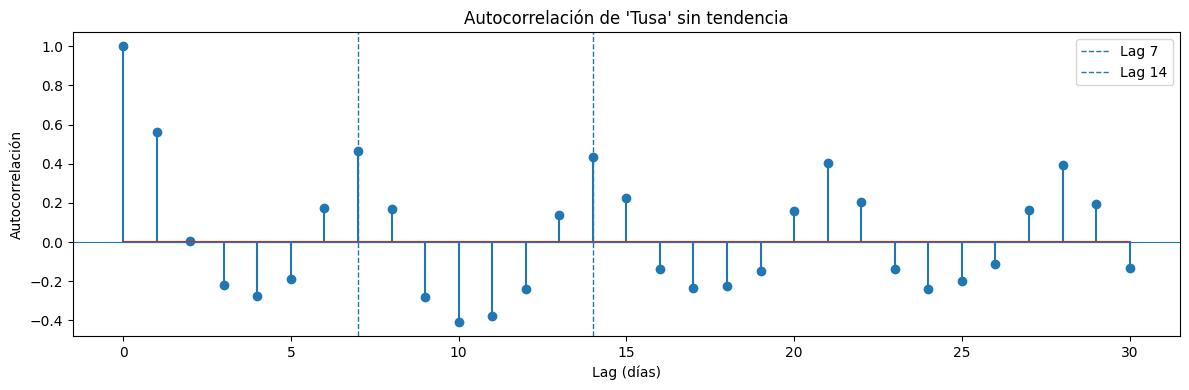

In [28]:
ac_tusa = utils.autocorrelacion(serie_sin_tendencia.dropna(), nlags=30)

plt.figure(figsize=(12, 4))
plt.stem(range(len(ac_tusa)), ac_tusa)
plt.axvline(7, linestyle="--", linewidth=1, label="Lag 7")
plt.axvline(14, linestyle="--", linewidth=1, label="Lag 14")
plt.axhline(0, linewidth=0.8)
plt.title("Autocorrelación de 'Tusa' sin tendencia")
plt.xlabel("Lag (días)")
plt.ylabel("Autocorrelación")
plt.legend()
plt.tight_layout()
plt.show()

La autocorrelación de la serie sin tendencia permite observar dependencia temporal entre los valores de streams. En particular, la presencia de valores relevantes en lags cercanos y en torno a los 7 días es coherente con el resultado obtenido mediante Fourier, donde apareció una periodicidad dominante cercana a una semana. Esto refuerza la idea de que la serie no se comporta como ruido aleatorio, sino que presenta estructura temporal.

En este notebook se analizó el ciclo de vida de **“Tusa”** en el Top 50 argentino de Spotify, tratándola como una señal temporal diaria de streams. La serie presentó 363 muestras entre noviembre de 2019 y enero de 2021, con un pico máximo de 708.411 streams el 18 de enero de 2020.

El análisis en el dominio del tiempo permitió observar una forma de onda asociada al ciclo de popularidad de la canción: crecimiento, pico y caída. Mediante medias móviles se separó la tendencia general de las fluctuaciones de corto plazo. Luego, el análisis de Fourier mostró una frecuencia dominante de aproximadamente 0.1433 ciclos por día, equivalente a un período de 6.98 días, lo que sugiere un patrón semanal en los streams.

Además, la energía calculada en tiempo y frecuencia coincidió, verificando el teorema de Parseval. Finalmente, la autocorrelación reforzó la presencia de estructura temporal en la serie. En conjunto, estos resultados muestran que el comportamiento de una canción en los charts puede caracterizarse mediante herramientas de análisis de señales y series temporales.